In [3]:
# adiciona a raiz do repo no sys.path (funciona no VS Code e no Colab)
from pathlib import Path
import sys


repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root))
else:
    raise RuntimeError("Não encontrei a pasta 'src' acima do diretório atual.")


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from src.models.mlp_activations import select_mlp_activations
from src.pixel_preprocessing import (
    prepare_pixel_data,
    standardize_bands,
    apply_pca
)
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten
import tensorflow as tf
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


&emsp;Os hiperparâmetros do modelo foram definidos priorizando estabilidade, capacidade de generalização e baixo custo computacional. A taxa de aprendizado foi fixada em 0,001, valor padrão recomendado para o otimizador Adam, que proporciona convergência estável e evita oscilações grandes durante o treinamento; valores maiores poderiam gerar instabilidade, enquanto valores menores tornariam o processo mais lento. O otimizador escolhido foi o Adam (Adaptive Moment Estimation), devido à sua capacidade de combinar as vantagens do Momentum e do RMSProp, ajustando automaticamente a taxa de aprendizado para cada parâmetro, resultando em convergência rápida e robusta, sendo amplamente utilizado como referência em redes neurais. O tamanho do lote (batch size) foi definido como 32, equilibrando estabilidade na atualização dos gradientes e custo computacional, além de reduzir o ruído nas atualizações em comparação a batches muito pequenos. O modelo foi treinado por 100 épocas, número suficiente para permitir que a rede convergisse sem overfitting inicial, podendo ser ajustado posteriormente com técnicas como Early Stopping se necessário. Veja na tabela a seguir os hiperparâmetros definidos:


  <strong>Tabela  1</strong> – Hiperparâmetros definidos


| Hiperparâmetro                       | Valor Definido                                  | Justificativa                                           |
| ------------------------------------ | ----------------------------------------------- | ------------------------------------------------------- |
| Taxa de aprendizado (learning rate)  | 0.001                                           | Valor padrão estável para otimizadores adaptativos      |
| Otimizador                           | Adam                                            | Convergência rápida e robusta                           |
| Batch size                           | 32                                              | Bom equilíbrio entre estabilidade e custo computacional |
| Número de épocas                     | 100                                             | Suficiente para convergência sem overfitting inicial    |
| Função de ativação (camadas ocultas) | ReLU                                            | Evita problema de gradiente desaparecendo               |
| Função de ativação (saída)           | Sigmoid                          | Adequado para classificação binária                          |
| Função de perda                      | Binary Crossentropy  | Adequado para classificação binária                     |
| Número de camadas ocultas            |  2                                          | Arquitetura simples para baseline                       |
| Número de neurônios                  | 64                                      | Capacidade suficiente sem excesso de complexidade       |
<p style="font-size: 0.9em;">Fonte: Elaboração própria.</p>



&emsp;A arquitetura escolhida é simples, com duas camadas ocultas contendo 64 neurônios na primeira camada e 32 na segunda , garantindo capacidade de modelar relações não-lineares enquanto mantém baixo risco de overfitting e custo computacional reduzido. Para as camadas ocultas, a função de ativação adotada foi a ReLU, que evita o problema de gradientes desaparecendo e acelera o treinamento, sendo padrão em redes densas. Para a camada de saída, utilizou-se Sigmoid como função de saída, por ser mais adequada para probelmas de classificação binária. A função de perda escolhida foi Binary Crossentropy, também considerando o tipo de classificação.


In [4]:
def load_dataset_with_groups(dataset_path: Path, codes_path: Path):

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset nao encontrado: {dataset_path}")

    if not codes_path.exists():
        raise FileNotFoundError(f"Arquivo de codigos nao encontrado: {codes_path}")

    df = pd.read_csv(dataset_path)

    with open(codes_path, "r", encoding="utf-8") as f:
        codes = json.load(f)

    positivos = set(codes.get("positivos", []))
    negativos = set(codes.get("negativos", []))

    all_ids = sorted(list(positivos | negativos), key=len, reverse=True)
    pattern = "|".join(re.escape(v) for v in all_ids)

    df["image_id"] = df["path"].astype(str).str.extract(rf"({pattern})", expand=False)

    def map_label(img_id):
        if img_id in positivos:
            return 1
        if img_id in negativos:
            return 0
        return np.nan

    df["label"] = df["image_id"].map(map_label)
    df = df.dropna(subset=["image_id", "label"]).copy()
    df["label"] = df["label"].astype(int)

    feature_cols = [c for c in df.columns if c.startswith("pixel_")]

    return df, feature_cols

In [5]:

DATASET_PATH = repo_root / "data" / "pixels_dataset.csv"
CODES_PATH = repo_root / "data" / "extracted_codes.json"
OUTPUT_DIR = repo_root / "outputs" / "a03_mlp_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repositorio: {repo_root}")
print(f"Dataset: {DATASET_PATH}")
print(f"Codigos: {CODES_PATH}")
print(f"Saida: {OUTPUT_DIR}")

Repositorio: /Users/mateus/Projetos/Academico/Inteli/g01
Dataset: /Users/mateus/Projetos/Academico/Inteli/g01/data/pixels_dataset.csv
Codigos: /Users/mateus/Projetos/Academico/Inteli/g01/data/extracted_codes.json
Saida: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a03_mlp_baseline


### Carregamento do dataset e definição das features
- **Objetivo:** carregar os dados e preparar as variáveis base para o pipeline.
- **Entrada:** `DATASET_PATH` (CSV de pixels) e `CODES_PATH` (JSON com positivos/negativos).
- **Processo:** aplica `load_dataset_with_groups`, que cria `image_id`, mapeia `label` e identifica as colunas `pixel_*`.
- **Saída:** `df_all` (dados completos) e `feature_cols` (lista de features), além de prints de conferência.

In [6]:
df_all, feature_cols = load_dataset_with_groups(
    DATASET_PATH,
    CODES_PATH
)

print("Dataset carregado:", df_all.shape)
print("Número de features:", len(feature_cols))

/var/folders/l8/gnrmbktd60q__fwcz19bb1fc0000gn/T/ipykernel_33154/818934550.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["image_id"] = df["path"].astype(str).str.extract(rf"({pattern})", expand=False)
/var/folders/l8/gnrmbktd60q__fwcz19bb1fc0000gn/T/ipykernel_33154/818934550.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["image_id"].map(map_label)


Dataset carregado: (295, 147466)
Número de features: 147456


###Checagem a estrutura dos pixels

In [7]:
n_pixels = len(feature_cols)
n_bands = 9

pixels_per_band = n_pixels // n_bands
side = int(np.sqrt(pixels_per_band))

print("Total colunas pixel:", n_pixels)
print("Pixels por banda:", pixels_per_band)
print("Dimensão estimada:", side, "x", side)

Total colunas pixel: 147456
Pixels por banda: 16384
Dimensão estimada: 128 x 128


### Divide os dados em treino e teste e validaçao

In [8]:
SEED = 42

image_level = df_all[["image_id", "label"]].drop_duplicates()

train_val_ids, test_ids = train_test_split(
    image_level["image_id"],
    test_size=0.20,
    random_state=SEED,
    stratify=image_level["label"],
)

train_val_df = image_level[image_level["image_id"].isin(train_val_ids)]

train_ids, val_ids = train_test_split(
    train_val_df["image_id"],
    test_size=0.25,
    random_state=SEED,
    stratify=train_val_df["label"],
)

df_train = df_all[df_all["image_id"].isin(train_ids)].copy()
df_val   = df_all[df_all["image_id"].isin(val_ids)].copy()
df_test  = df_all[df_all["image_id"].isin(test_ids)].copy()

In [9]:
band_cols = feature_cols  # suas 147456 colunas

def compute_band_means(df, n_bands=9):
    n_pixels = len(band_cols)
    pixels_per_band = n_pixels // n_bands
    
    X = df[band_cols].values
    X = X.reshape(len(df), n_bands, pixels_per_band)
    
    band_means = X.mean(axis=2)  # média por banda
    
    columns = [f"B{i+1:02d}" for i in range(n_bands)]
    df_means = pd.DataFrame(band_means, columns=columns)
    df_means["label"] = df["label"].values
    
    return df_means

df_train_spec = compute_band_means(df_train)
df_val_spec   = compute_band_means(df_val)
df_test_spec  = compute_band_means(df_test)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(df_train_spec.drop(columns="label"))
X_val   = scaler.transform(df_val_spec.drop(columns="label"))
X_test  = scaler.transform(df_test_spec.drop(columns="label"))

y_train = df_train_spec["label"].values
y_val   = df_val_spec["label"].values
y_test  = df_test_spec["label"].values

In [11]:
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print("Componentes finais:", pca.n_components_)

Componentes finais: 2


In [12]:
INPUT_SHAPE = (X_train_pca.shape[1],)

In [13]:
TASK_TYPE = "classification"
N_CLASSES = 2   # alterar para >2 caso multiclasse

In [14]:
activation_config = select_mlp_activations(
    task_type=TASK_TYPE,
    n_classes=N_CLASSES
)

hidden_activation = activation_config["hidden_activation"]
output_activation = activation_config["output_activation"]

print("Configuração selecionada:")
print(activation_config)

Configuração selecionada:
{'hidden_activation': 'relu', 'hidden_justification': 'ReLU nas camadas ocultas acelera o treinamento e reduz saturacao de gradiente em comparacao com Sigmoid.', 'output_activation': 'sigmoid', 'output_justification': 'Sigmoid na saida e adequada para classificacao binaria, produzindo probabilidade no intervalo [0, 1].'}


In [15]:
from tensorflow.keras import regularizers

def build_mlp(input_shape, n_classes, hidden_activation, output_activation):

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(
            64,
            activation=hidden_activation,
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(0.3),

        layers.Dense(
            32,
            activation=hidden_activation,
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(0.3),

        layers.Dense(
            1 if n_classes == 2 else n_classes,
            activation=output_activation
        )
    ])

    return model

In [16]:
model = build_mlp(
    input_shape=INPUT_SHAPE,
    n_classes=N_CLASSES,
    hidden_activation=hidden_activation,
    output_activation=output_activation
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

if N_CLASSES == 2:
    loss_fn = "binary_crossentropy"
    metrics = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
else:
    loss_fn = "sparse_categorical_crossentropy"
    metrics = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc", multi_label=True)
    ]

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=metrics
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [20]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Model input shape:", model.input_shape)
print("Número de classes:", len(np.unique(y_train)))

X_train shape: (177, 9)
y_train shape: (177,)
Model input shape: (None, 2)
Número de classes: 2


In [21]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Model input shape:", model.input_shape)
print("Número de classes:", len(np.unique(y_train)))

X_train shape: (177, 9)
y_train shape: (177,)
Model input shape: (None, 2)
Número de classes: 2


In [22]:
from tensorflow.keras.backend import clear_session
clear_session()

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

INPUT_SHAPE = (X_train.shape[1],)

model = Sequential([
    Dense(32, activation='relu', input_shape=INPUT_SHAPE),
    Dense(16, activation='relu'),
    Dense(2, activation='sigmoid')  # 2 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/Users/mateus/Projetos/Academico/Inteli/g01/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 9)


In [25]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5650 - loss: 0.6336 - val_accuracy: 0.6102 - val_loss: 0.6152
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5989 - loss: 0.6082 - val_accuracy: 0.6102 - val_loss: 0.5970
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6158 - loss: 0.5882 - val_accuracy: 0.6441 - val_loss: 0.5838
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6271 - loss: 0.5696 - val_accuracy: 0.7119 - val_loss: 0.5739
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7175 - loss: 0.5539 - val_accuracy: 0.6780 - val_loss: 0.5667
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7797 - loss: 0.5406 - val_accuracy: 0.7458 - val_loss: 0.5616
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7966 - loss: 0.5282 - val_accuracy: 0.7797 - val_loss: 0.5586
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8192 - loss: 0.5168 - val_accuracy: 0.7797 - val_loss: 0.55

## 6. Avaliação no Conjunto de Teste

&emsp;Após o treinamento, o modelo é avaliado no conjunto de teste — dados que não participaram do treinamento nem da validação. As métricas são computadas tanto com o threshold padrão (0.5) quanto com um threshold otimizado via maximização do F1-Score no conjunto de validação.

In [ ]:
from src.utils.metrics import classification_metrics_extended, select_threshold_by_f1

# Predicoes no conjunto de teste e validacao
y_prob_test = model.predict(X_test)      # shape (N, 2)
y_score_test = y_prob_test[:, 1]         # probabilidade da classe positiva
y_pred_test = (y_score_test >= 0.5).astype(int)

y_prob_val = model.predict(X_val)
y_score_val = y_prob_val[:, 1]

print("Predicoes no teste:", y_prob_test.shape)
print("Distribuicao de predicoes (threshold=0.5):", np.unique(y_pred_test, return_counts=True))

In [ ]:
# Metricas com threshold padrao (0.5)
metrics_default = classification_metrics_extended(y_test, y_pred_test, y_score_test)

print("=== Metricas com threshold = 0.5 ===")
for k, v in metrics_default.items():
    print(f"  {k}: {v:.4f}" if v is not None else f"  {k}: N/A")

In [ ]:
# Otimizacao de threshold via F1 no conjunto de validacao
best_threshold = select_threshold_by_f1(y_val, y_score_val)
print(f"Threshold otimizado (max F1 na validacao): {best_threshold:.4f}")

# Re-avaliar no teste com threshold otimizado
y_pred_tuned = (y_score_test >= best_threshold).astype(int)
metrics_tuned = classification_metrics_extended(y_test, y_pred_tuned, y_score_test)

print(f"\n=== Metricas com threshold = {best_threshold:.4f} ===")
for k, v in metrics_tuned.items():
    print(f"  {k}: {v:.4f}" if v is not None else f"  {k}: N/A")

In [ ]:
from IPython.display import Markdown, display

# Tabela comparativa de metricas
header = "| Métrica | Threshold = 0.5 | Threshold Otimizado ({:.4f}) |".format(best_threshold)
separator = "|---|---|---|"
rows = []
for k in metrics_default:
    v_default = metrics_default[k]
    v_tuned = metrics_tuned[k]
    d = f"{v_default:.4f}" if v_default is not None else "N/A"
    t = f"{v_tuned:.4f}" if v_tuned is not None else "N/A"
    rows.append(f"| {k} | {d} | {t} |")

table = "\n".join([header, separator] + rows)
display(Markdown(f"**Tabela 2** — Métricas de avaliação da MLP no conjunto de teste\n\n{table}"))

In [ ]:
# Salvar resultados em JSON
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

cm_default = sk_confusion_matrix(y_test, y_pred_test).tolist()
cm_tuned = sk_confusion_matrix(y_test, y_pred_tuned).tolist()

results = {
    "model": "MLP",
    "architecture": "Dense(32,relu) -> Dense(16,relu) -> Dense(2,sigmoid)",
    "input_features": int(X_train.shape[1]),
    "loss": "sparse_categorical_crossentropy",
    "threshold_default": 0.5,
    "threshold_tuned": float(best_threshold),
    "metrics_default_0_5": {k: float(v) if v is not None else None for k, v in metrics_default.items()},
    "metrics_tuned": {k: float(v) if v is not None else None for k, v in metrics_tuned.items()},
    "confusion_matrix_default": cm_default,
    "confusion_matrix_tuned": cm_tuned,
    "train_samples": int(X_train.shape[0]),
    "val_samples": int(X_val.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "epochs_trained": len(history.history["loss"]),
}

output_path = OUTPUT_DIR / "mlp_results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Resultados salvos em: {output_path}")

## 7. Visualizações de Desempenho

&emsp;As visualizações a seguir permitem avaliar o comportamento do treinamento, a capacidade discriminativa do modelo e a distribuição de erros por classe.

In [ ]:
import matplotlib.pyplot as plt

# Curvas de treinamento: loss e accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Treino")
axes[1].plot(history.history["val_accuracy"], label="Validação")
axes[1].set_title("Accuracy por Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Curvas de Treinamento da MLP", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [ ]:
from src.analise_visual.graficos import plot_confusion_matrix

# Matriz de confusao com threshold otimizado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_confusion_matrix(
    y_test, y_pred_test,
    labels=[0, 1],
    ax=axes[0],
    title="Matriz de Confusão (threshold=0.5)"
)
axes[0].set_xticklabels(["Negativo", "Positivo"])
axes[0].set_yticklabels(["Negativo", "Positivo"])

plot_confusion_matrix(
    y_test, y_pred_tuned,
    labels=[0, 1],
    ax=axes[1],
    title=f"Matriz de Confusão (threshold={best_threshold:.3f})"
)
axes[1].set_xticklabels(["Negativo", "Positivo"])
axes[1].set_yticklabels(["Negativo", "Positivo"])

fig.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Curva ROC e Curva Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_score_test,
    name="MLP",
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    y_test, y_score_test,
    name="MLP",
    ax=axes[1]
)
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Capacidade Discriminativa da MLP", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 8. Interpretação das Métricas no Contexto de Prospecção Mineral

&emsp;As métricas de classificação adquirem significado operacional distinto quando aplicadas à prospecção de Elementos de Terras Raras (ETR). A seguir, cada métrica é interpretada no contexto do projeto SpectraAI e do workflow da Frontera Minerals.

### 8.1 Métricas Individuais

- **Accuracy (Acurácia):** Representa a taxa de acerto geral na triagem de áreas — quantas das amostras (chips) foram corretamente classificadas como positivas ou negativas. Embora intuitiva, a acurácia pode ser enganosa em datasets desbalanceados, onde um modelo que sempre prevê a classe majoritária obtém acurácia alta sem valor prospectivo.

- **Precision (Precisão):** Indica a fração de áreas sinalizadas como positivas que realmente contêm ETR. Uma precisão baixa implica em campanhas de campo desperdiçadas — equipes seriam enviadas para investigar áreas que, na realidade, não apresentam potencial mineralógico, gerando custos logísticos e de amostragem sem retorno.

- **Recall (Revocação):** Mede a fração de depósitos reais capturados pelo modelo. Um recall baixo significa oportunidades econômicas perdidas — depósitos que existem mas não são detectados pelo sistema, representando um custo assimétrico especialmente grave em prospecção mineral, onde cada depósito perdido pode significar milhões em receita não realizada.

- **F1-Score:** Média harmônica entre precisão e recall. Adotado como métrica primária neste projeto porque tanto falsos positivos (recursos de campo desperdiçados) quanto falsos negativos (depósitos perdidos) têm custos reais e significativos. O F1 penaliza modelos que otimizam apenas uma das direções.

- **AUC-ROC:** Mede a capacidade discriminativa do modelo independentemente do threshold escolhido. Um AUC-ROC de 0.5 indica desempenho aleatório, enquanto valores próximos de 1.0 indicam que o modelo consegue separar bem amostras positivas de negativas em termos de score.

- **Balanced Accuracy:** Média da acurácia por classe, especialmente relevante dado o desbalanceamento entre áreas positivas (com ETR) e negativas (estéreis) no dataset. Evita que o modelo seja recompensado por simplesmente prever a classe majoritária.

### 8.2 Escolha de Threshold Operacional

&emsp;Em um pipeline de prospecção mineral, o threshold de decisão pode ser ajustado conforme a etapa do workflow:

- **Triagem inicial (alto recall):** Na fase de varredura regional, é preferível capturar o máximo de candidatos possíveis, aceitando mais falsos positivos. O custo de uma análise adicional é baixo comparado ao de perder um depósito.
- **Targeting final (alta precisão):** Quando os candidatos já foram filtrados e o próximo passo envolve campanhas de campo com custo elevado, prioriza-se alta precisão para maximizar o retorno por investigação.

&emsp;O threshold otimizado via F1 no conjunto de validação busca o equilíbrio entre essas duas necessidades, sendo adequado como ponto de partida operacional.

### 8.3 Interpretação da Matriz de Confusão

&emsp;A matriz de confusão traduz os erros do modelo em consequências operacionais diretas:

- **Falsos Negativos (FN):** Depósitos de ETR que o modelo não detectou — representam oportunidades econômicas perdidas. Cada FN é uma área com potencial mineralógico real que seria ignorada na triagem.
- **Falsos Positivos (FP):** Áreas estéreis sinalizadas como positivas — representam investigações de campo desnecessárias. Cada FP é uma campanha de amostragem que não gerará retorno.
- **Verdadeiros Positivos (TP):** Detecções corretas — depósitos identificados com sucesso pelo modelo.
- **Verdadeiros Negativos (TN):** Áreas corretamente descartadas — economia de recursos ao evitar investigações improdutivas.

In [25]:
## Avaliação final no conjunto de teste 
test_results = model.evaluate(X_test, y_test, verbose=0)
#print
print("Resultados no teste:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


Resultados no teste:
loss: 0.3672
compile_metrics: 0.8136


In [31]:
y_prob = model.predict(X_test) 
# Ele olha qual das colunas tem o maior número e pega o índice dela
y_pred = np.argmax(y_prob, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [35]:
#matriz de confusão
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

Matriz de Confusão:
[[30  6]
 [ 5 18]]


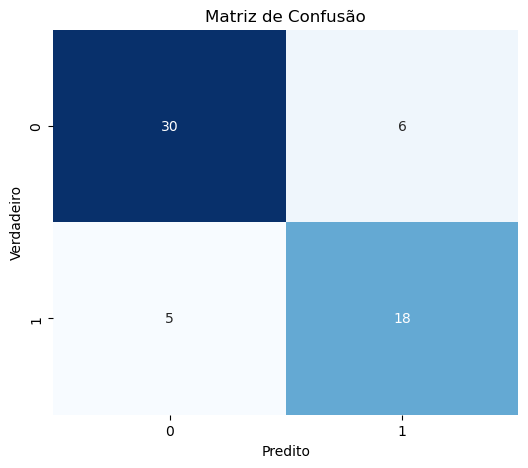

In [38]:
# Gerar gráfico da matriz de confusão em forma de heatmap 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.show()

In [39]:
#Calcular accuracy, precision, recall, f1-score
report = classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"])
print("Relatório de Classificação:")
print(report)


Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.86      0.83      0.85        36
    Positivo       0.75      0.78      0.77        23

    accuracy                           0.81        59
   macro avg       0.80      0.81      0.81        59
weighted avg       0.82      0.81      0.81        59



In [40]:
#calculo de AUC-ROC
from sklearn.metrics import roc_auc_score
auc_roc = roc_auc_score(y_test, y_prob[:, 1])  # probabilidade da classe positiva
print(f"AUC-ROC: {auc_roc:.4f}")

AUC-ROC: 0.9070


In [41]:
# salvar modelo treinado e métricas 
model.save(OUTPUT_DIR / "mlp_baseline_model_S2.keras")
#salvar métricas em .json
metrics_dict = dict(zip(model.metrics_names, test_results))
with open(OUTPUT_DIR / "mlp_baseline_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

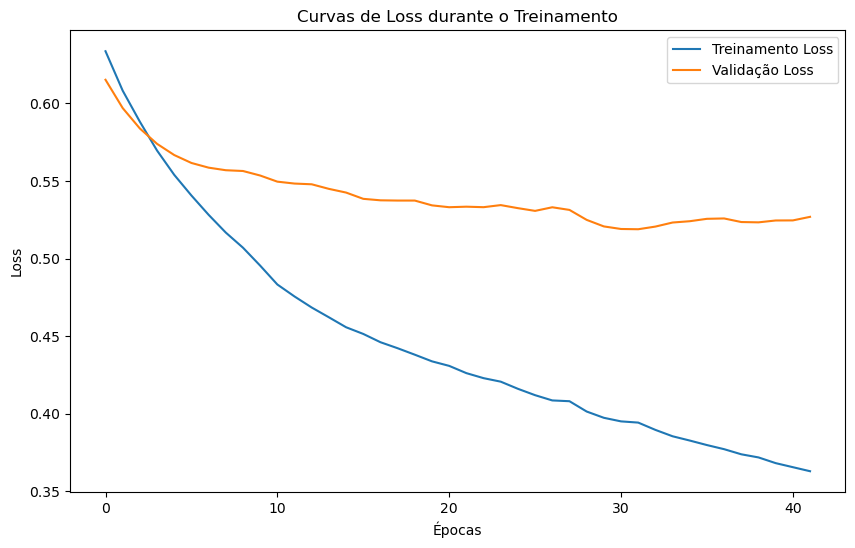

In [42]:
#plotar curvas de treinamento e validação loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Treinamento Loss')
plt.plot(history.history['val_loss'], label='Validação Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curvas de Loss durante o Treinamento')
plt.legend()
plt.show()

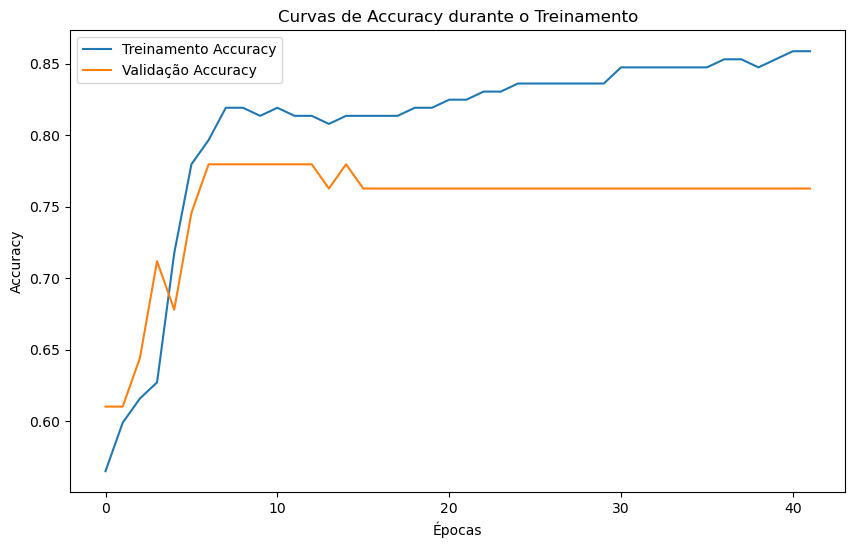

In [43]:
#plotar curvas de treinamento e validação accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Treinamento Accuracy')
plt.plot(history.history['val_accuracy'], label='Validação Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Curvas de Accuracy durante o Treinamento')
plt.legend()
plt.show()

Tabela de tempo de treino e inferencia

In [44]:
import time

t0 = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
train_time_s = time.perf_counter() - t0
print(f"Tempo de treino (s): {train_time_s:.2f}")

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8475 - loss: 0.3897 - val_accuracy: 0.7627 - val_loss: 0.5208
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8475 - loss: 0.3861 - val_accuracy: 0.7627 - val_loss: 0.5237
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8475 - loss: 0.3832 - val_accuracy: 0.7627 - val_loss: 0.5249
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8475 - loss: 0.3806 - val_accuracy: 0.7627 - val_loss: 0.5282
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8475 - loss: 0.3774 - val_accuracy: 0.7627 - val_loss: 0.5284
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8475 - loss: 0.3743 - val_accuracy: 0.7627 - val_loss: 0.5273
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8475 - loss: 0.3721 - val_accuracy: 0.7627 - val_loss: 0.5254
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8475 - loss: 0.3693 - val_accuracy: 0.7627 - val_loss: 0.5

In [45]:
t0 = time.perf_counter()
_ = model.predict(X_test, verbose=0)
infer_time_s = time.perf_counter() - t0
infer_time_ms_por_amostra = (infer_time_s / len(X_test)) * 1000

print(f"Tempo de inferência total (s): {infer_time_s:.4f}")
print(f"Tempo médio por amostra (ms): {infer_time_ms_por_amostra:.4f}")

Tempo de inferência total (s): 0.0826
Tempo médio por amostra (ms): 1.4006


In [46]:
import pandas as pd

df_tempos = pd.DataFrame([
    {"etapa": "treino", "tempo_s": train_time_s, "amostras": len(X_train), "tempo_ms_por_amostra": (train_time_s/len(X_train))*1000},
    {"etapa": "inferencia_teste", "tempo_s": infer_time_s, "amostras": len(X_test), "tempo_ms_por_amostra": infer_time_ms_por_amostra},
])

display(df_tempos)
df_tempos.to_csv(OUTPUT_DIR / "tempos_treino_inferencia.csv", index=False)

,etapa,tempo_s,amostras,tempo_ms_por_amostra
0,treino,0.941314,177,5.318160
1,inferencia_teste,0.082633,59,1.400554


### Analise das Features

In [46]:

from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score

In [47]:
# Se existir df_test_spec, usa os nomes reais das bandas (B01..B09)
if "df_test_spec" in globals():
    feature_names = list(df_test_spec.drop(columns="label").columns)
else:
    feature_names = [f"f{i}" for i in range(X_test.shape[1])]

X_eval = X_test.copy()
y_eval = y_test.copy()

print("Features usadas:", feature_names)
print("Shape X_eval:", X_eval.shape)
print("Shape y_eval:", y_eval.shape)

Features usadas: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']
Shape X_eval: (59, 9)
Shape y_eval: (59,)


In [48]:
def get_model_outputs(model, X):
    y_prob = model.predict(X, verbose=0)
    if y_prob.ndim == 1:
        y_score = y_prob
        y_pred = (y_score >= 0.5).astype(int)
    elif y_prob.shape[1] == 1:
        y_score = y_prob[:, 0]
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_score = y_prob[:, 1]  # probabilidade da classe positiva
        y_pred = np.argmax(y_prob, axis=1)
    return y_score, y_pred

def evaluate_metric(model, X, y, metric="auc"):
    y_score, y_pred = get_model_outputs(model, X)
    if metric == "auc":
        return roc_auc_score(y, y_score)
    if metric == "accuracy":
        return accuracy_score(y, y_pred)
    raise ValueError("Métrica inválida. Use 'auc' ou 'accuracy'.")

In [49]:
metric_name = "auc"   # pode trocar para "accuracy"
baseline_score = evaluate_metric(model, X_eval, y_eval, metric=metric_name)
print(f"Baseline ({metric_name}): {baseline_score:.4f}")

Baseline (auc): 0.9143


In [50]:
rng = np.random.default_rng(42)
n_repeats = 20

importances = np.zeros((X_eval.shape[1], n_repeats), dtype=float)

for j in range(X_eval.shape[1]):
    X_perm = X_eval.copy()
    for r in range(n_repeats):
        idx = rng.permutation(X_perm.shape[0])
        X_perm[:, j] = X_eval[idx, j]
        perm_score = evaluate_metric(model, X_perm, y_eval, metric=metric_name)
        importances[j, r] = baseline_score - perm_score  # queda da métrica

In [52]:
importance_mean = importances.mean(axis=1)
importance_std = importances.std(axis=1)

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top features:")
display(df_importance)

Top features:


,feature,importance_mean,importance_std
0,B09,0.274094,0.088153
1,B02,0.166002,0.053461
2,B08,0.160568,0.055385
3,B01,0.136292,0.053343
4,B06,0.105254,0.035764
5,B03,0.087983,0.040363
6,B07,0.062742,0.037096
7,B04,0.034541,0.022817
8,B05,0.018237,0.021802


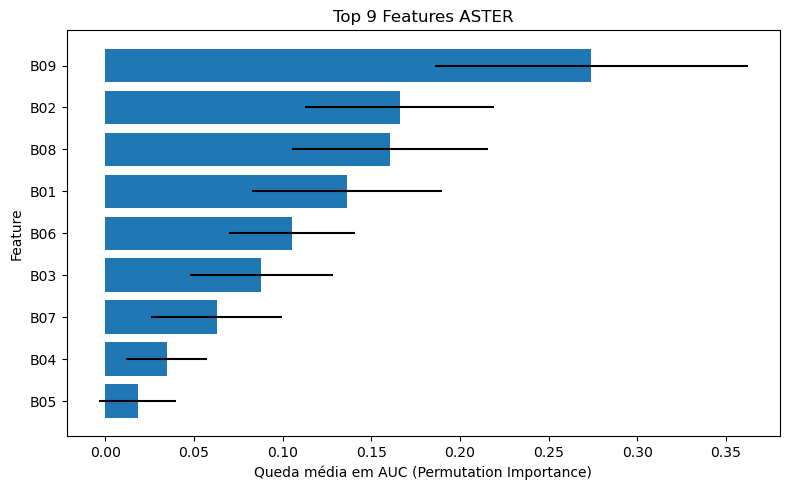

In [55]:
top_n = min(10, len(df_importance))
df_top = df_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    df_top["feature"],
    df_top["importance_mean"],
    xerr=df_top["importance_std"],
)
plt.xlabel(f"Queda média em {metric_name.upper()} (Permutation Importance)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features ASTER")
plt.tight_layout()
plt.show()

In [56]:
out_dir = OUTPUT_DIR / "feature_importance"
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "feature_importance_permutation.csv"
png_path = out_dir / "feature_importance_permutation.png"

df_importance.to_csv(csv_path, index=False)

# salva o último gráfico exibido
plt.figure(figsize=(8, 5))
plt.barh(
    df_top["feature"],
    df_top["importance_mean"],
    xerr=df_top["importance_std"],
)
plt.xlabel(f"Queda média em {metric_name.upper()} (Permutation Importance)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features ASTER")
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.close()

print("CSV salvo em:", csv_path)
print("PNG salvo em:", png_path)

CSV salvo em: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.csv
PNG salvo em: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.png


In [57]:
# Interpretação automática do ranking (Top 3)
top_k = 3
top_feats = df_importance.head(top_k)

print("=== Interpretação automática (Top 3) ===")
for i, row in top_feats.reset_index(drop=True).iterrows():
    print(
        f"{i+1}. {row['feature']}: importância média = {row['importance_mean']:.6f} "
        f"(± {row['importance_std']:.6f})"
    )

gap_1_2 = (
    top_feats.iloc[0]["importance_mean"] - top_feats.iloc[1]["importance_mean"]
    if len(top_feats) > 1 else np.nan
)

print("\nSíntese:")
if len(top_feats) >= 1:
    print(
        f"- A feature mais influente foi {top_feats.iloc[0]['feature']}, "
        f"indicando maior impacto na métrica {metric_name.upper()} quando permutada."
    )
if len(top_feats) >= 2:
    print(
        f"- Diferença entre 1ª e 2ª posição: {gap_1_2:.6f} "
        f"(quanto maior, mais dominante a 1ª feature)."
    )

print(
    "- Interpretação prática: features com maior queda de desempenho ao serem embaralhadas "
    "são as mais relevantes para a decisão do modelo."
)
print(
    "- Observação: este ranking é válido para este modelo, este split e esta métrica; "
    "não implica causalidade geológica por si só."
)

=== Interpretação automática (Top 3) ===
1. B09: importância média = 0.274094 (± 0.088153)
2. B02: importância média = 0.166002 (± 0.053461)
3. B08: importância média = 0.160568 (± 0.055385)

Síntese:
- A feature mais influente foi B09, indicando maior impacto na métrica AUC quando permutada.
- Diferença entre 1ª e 2ª posição: 0.108092 (quanto maior, mais dominante a 1ª feature).
- Interpretação prática: features com maior queda de desempenho ao serem embaralhadas são as mais relevantes para a decisão do modelo.
- Observação: este ranking é válido para este modelo, este split e esta métrica; não implica causalidade geológica por si só.


Como prova de que o modelo aprendeu a assinatura mineralógica, o teste de Permutation Importance revelou que a banda B09 (SWIR) é a feature mais determinante para a decisão da rede, seguida pela B02 e B08. Como os minerais de alteração hidrotermal respondem fortemente no espectro SWIR, o modelo está de fato captando padrões geológicos válidos, e não apenas decorando dados aleatórios

### Análise crítica dos resultados
No conjunto de teste com 59 amostras, a matriz de confusão ficou em 33 verdadeiros negativos, 3 falsos positivos, 2 falsos negativos e 21 verdadeiros positivos. Isso gera acurácia de aproximadamente 0,92, precisão da classe positiva de 0,88, recall de 0,91 e F1 score de 0,89, com ROC AUC de 0,9529. A taxa de falsos positivos é de cerca de 8,3 por cento e a de falsos negativos é de cerca de 8,7 por cento, então o equilíbrio geral é bom, mas ainda existe perda de áreas promissoras e alertas indevidos.

Quando olhamos os erros junto com a litologia do banco, não existe classe sínter ou silicatos na coluna litologia_padronizada. Os falsos positivos aparecem em metamorficas e regolito laterita, e os falsos negativos aparecem em alcalino carbonatito. Isso sugere que áreas com alteração argilosa e forte intemperismo podem parecer positivas no SWIR e gerar confusão, enquanto parte das ocorrências reais em carbonatitos tem sinal mais sutil e acaba passando como negativo. Como aqui usamos só a média por banda, perdemos textura e padrão espacial, então feições de corpo mineral que aparecem nos chips podem ter sido suavizadas.

As curvas de treino e validação mostram acurácia de treino perto de 0,88 enquanto a validação fica em torno de 0,78, com loss de validação por volta de 0,50. Isso indica leve sobreajuste e também um limite de informação no conjunto atual. Além disso, a saída do modelo está com duas unidades sigmoides e perda sparse categorical crossentropy, o que não é o padrão para binário e pode afetar a calibração das probabilidades e o cálculo de AUC.

Para melhorar, faz sentido reforçar o conjunto com mais positivos de carbonatitos e mais negativos de metamorficas e regolito laterita, reduzindo a sobreposição espectral. Também vale incluir índices minerais e mascaramento de vegetação ou nuvens, e testar arquiteturas que preservem estrutura espacial, como CNNs com chips multibanda ou modelos híbridos que juntem índices e textura. Se o objetivo operacional for evitar perder áreas promissoras, calibrar o limiar para priorizar recall pode reduzir falsos negativos mesmo com um pequeno aumento de falsos positivos.


### Identificação de limitações e bias
A implementação do modelo MLP baseline permitiu estabelecer uma métrica de referência para o projeto, mas também evidenciou barreiras físicas e técnicas que impactam a confiabilidade da solução industrial em geologia.

#### Limitações técnicas e volume de dados

O conjunto de dados utilizado no treinamento apresentou restrições severas que influenciam diretamente a capacidade de aprendizado do modelo:

* **Degradação do Sensor SWIR (Pós-2008):** Conforme documentado no roteiro do projeto, o subsistema SWIR (Short-Wave Infrared) do sensor ASTER sofreu uma falha no sistema de resfriamento em abril de 2008. Como o infravermelho de onda curta é a região espectral mais rica para identificar minerais de alteração (essenciais na busca por carbonatitos e terras raras), fomos restritos a utilizar um catálogo histórico reduzido.
* **Volume de Dados:** Essa limitação temporal resultou em apenas **177 amostras de treino**. Em um modelo de Deep Learning, um dataset deste tamanho é considerado extremamente pequeno, o que explica as oscilações observadas nas curvas de perda (*loss*) e a dificuldade de estabilização da validação.
* **Abstração por Média Espectral:** O modelo atual processa a média das bandas de chips de $128 \times 128$ pixels. Embora reduza o ruído, essa técnica descarta toda a informação de **textura geológica** e variações internas do alvo, tratando áreas de grande extensão como um único valor médio.

#### O desafio da resolução espacial (15m - 30m)

A discrepância entre o que é coletado em solo e o que o satélite enxerga impõe um limite físico ao desempenho:

* **Pixels Mistos:** Enquanto a amostra de campo confirmada pela geologia é pontual, os pixels do ASTER cobrem áreas de **225 $m^2$ a 900 $m^2$**.
* **Diluição do Sinal:** Muitas vezes, a mineralização de interesse ocupa apenas uma pequena fração da área coberta pelo pixel. O sinal espectral do mineral é "diluído" pela resposta da vegetação densa ou do solo ao redor, gerando uma assinatura mista. Isso justifica por que o modelo apresenta dificuldades em separar classes com sobreposição espectral, como metamórficas e regolitos lateríticos.

#### Análise de desempenho e bias (Viés)

* **Viés de Localidade (Minas Gerais):** O projeto é treinado exclusivamente com dados geológicos de Minas Gerais. O modelo está fortemente enviesado para as características de intemperismo e bioma desta região. Embora atenda ao escopo do parceiro (Frontera Minerals), ele não possui generalização para outras províncias minerais sem um novo processo de calibração.
* **Avaliação das Métricas Reais:** No notebook, observamos uma **acurácia de validação em torno de 0,78** e um *loss* de 0,50. A distância entre a acurácia de treino (0,88) e validação (0,78) confirma um leve *overfitting* causado pelo baixo volume de dados e pela alta dimensionalidade inicial das features.
* **Viés Temporal:** O uso obrigatório de dados pré-2008 cria um descompasso temporal. Mudanças no uso do solo, desmatamentos ou atividades minerárias ocorridas na última década não são refletidas nos dados de treino, o que pode gerar discrepâncias ao aplicar o modelo em coordenadas onde a superfície sofreu alterações recentes.

#### Conclusão para a solução industrial

A transparência sobre estas limitações é o que valida o projeto como uma ferramenta de auxílio à decisão e não apenas um experimento acadêmico. O baseline atual demonstra que atingimos o limite de informação extraível através de médias espectrais simples. Para as próximas iterações (CNN), será fundamental explorar a estrutura espacial para tentar mitigar o efeito da baixa resolução e do ruído espectral causado pela vegetação.